In [2]:
import pandas as pd
import numpy as np

full = pd.read_csv("full_structural_homology_metrics.tsv", sep="\t")

print(full.shape)
full.head()

(90, 39)


,repA,repB,n_same_cell,n_cell_same_plasmid,cointegration_rate,ci_low,ci_high,category,rep_pair,n,...,p_bp_gt_500,p_bp_gt_1000,p_bp_gt_5000,p_bp_gt_10000,mean_cov,median_cov,max_cov,p_cov_gt_001,p_cov_gt_01,p_cov_gt_05
0,IncFIB,IncFII,3035,2410,0.794069,0.779238,0.808332,MIXED,IncFIB || IncFII,1291,...,0.961565,0.814335,0.342032,0.174475,0.044112,0.025148,0.732715,0.996694,0.775798,0.295261
1,IncFIB,rep_cluster_2183,1051,825,0.784967,0.758872,0.809455,MIXED,IncFIB || rep_cluster_2183,365,...,0.952011,0.844171,0.245384,0.087682,0.032449,0.018672,0.416690,0.995273,0.734279,0.200250
2,IncFII,IncR,776,383,0.493557,0.457818,0.529345,MIXED,IncFII || IncR,214,...,0.970049,0.835465,0.300791,0.107269,0.050638,0.033406,0.579643,0.999647,0.901793,0.355486
3,IncFII,rep_cluster_2183,1139,1126,0.988586,0.980562,0.993909,STRONG_COINTEGRATION,IncFII || rep_cluster_2183,656,...,0.929512,0.775009,0.275899,0.148451,0.058603,0.024838,0.629444,0.994660,0.768601,0.286935
4,IncR,rep_cluster_2183,370,90,0.243243,0.200382,0.290266,MIXED,IncR || rep_cluster_2183,98,...,0.965790,0.903645,0.258590,0.055871,0.039585,0.028797,0.392824,1.000000,0.879743,0.280400


In [3]:
features = [
    "cointegration_rate",
    "median_rel",
    "median_abs",
    "QCV_abs",
    "QCV_rel",
    "mantel_r",
    "mean_bp_log10",
    "mean_cov"
]

X = full[features].dropna().copy()

pair_ids = full.loc[X.index, "rep_pair_fixed"]
categories = full.loc[X.index, "category"]

print("Pairs used:", len(X))

Pairs used: 90


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.decomposition import PCA

pca = PCA()
pcs = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_

print("Explained variance per PC:")
for i, var in enumerate(explained[:5]):
    print(f"PC{i+1}: {var:.3f}")

Explained variance per PC:
PC1: 0.319
PC2: 0.210
PC3: 0.178
PC4: 0.123
PC5: 0.079


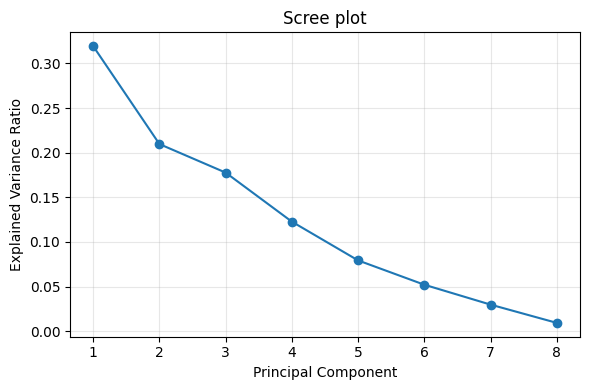

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1,len(explained)+1), explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

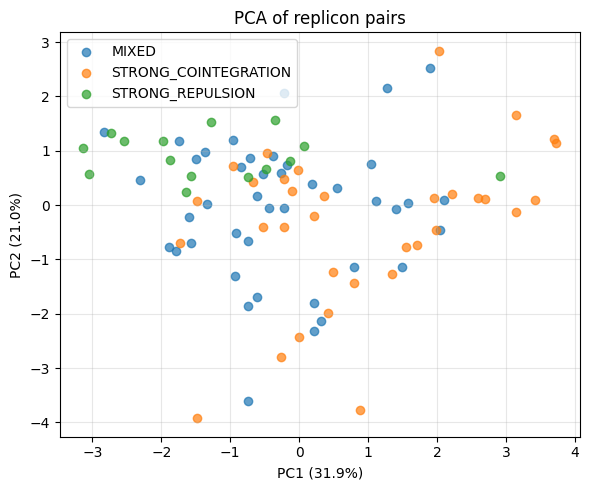

In [8]:
plt.figure(figsize=(6,5))

for cat in categories.unique():
    mask = categories == cat
    plt.scatter(
        pcs[mask,0],
        pcs[mask,1],
        label=cat,
        alpha=0.7
    )

plt.xlabel(f"PC1 ({explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}%)")
plt.legend()
plt.title("PCA of replicon pairs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

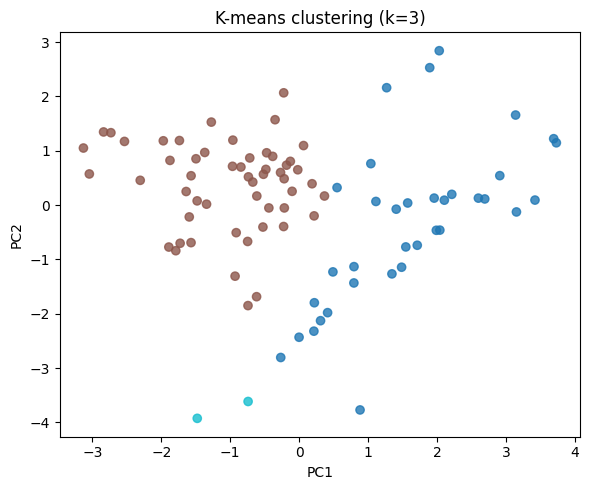

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(pcs[:,0], pcs[:,1], c=clusters, cmap="tab10", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clustering (k=3)")
plt.tight_layout()
plt.show()

In [21]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

# ------------------------------------------------------------
# DISTANCE MATRIX
# ------------------------------------------------------------

dist = squareform(pdist(X_scaled, metric="euclidean"))
groups = categories.values
unique_groups = np.unique(groups)

n = len(groups)

# ------------------------------------------------------------
# FUNCTION: compute pseudo-F
# ------------------------------------------------------------

def compute_pseudoF(dist_matrix, labels):
    unique = np.unique(labels)
    n = len(labels)

    grand_mean = dist_matrix.mean()

    ss_between = 0
    ss_within = 0

    for g in unique:
        idx = np.where(labels == g)[0]
        sub = dist_matrix[np.ix_(idx, idx)]

        group_mean = dist_matrix[idx].mean()

        ss_between += len(idx) * (group_mean - grand_mean)**2
        ss_within += np.sum((sub - sub.mean())**2)

    df_between = len(unique) - 1
    df_within = n - len(unique)

    F = (ss_between/df_between) / (ss_within/df_within)
    return F

# ------------------------------------------------------------
# OBSERVED F
# ------------------------------------------------------------

F_obs = compute_pseudoF(dist, groups)

# ------------------------------------------------------------
# PERMUTATION TEST
# ------------------------------------------------------------

n_perm = 2000
F_perm = []

for i in range(n_perm):
    perm_labels = np.random.permutation(groups)
    F_perm.append(compute_pseudoF(dist, perm_labels))

F_perm = np.array(F_perm)

p_value = np.mean(F_perm >= F_obs)

print("PERMANOVA results")
print("Pseudo-F:", round(F_obs,3))
print("p-value:", p_value)

PERMANOVA results
Pseudo-F: 0.012
p-value: 0.1635


In [22]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(len(features))]
)

print(loadings["PC1"].sort_values(ascending=False))
print(loadings["PC2"].sort_values(ascending=False))

QCV_rel               0.522468
QCV_abs               0.412437
cointegration_rate    0.261856
mean_cov              0.063319
mean_bp_log10        -0.125181
mantel_r             -0.213967
median_abs           -0.455214
median_rel           -0.464406
Name: PC1, dtype: float64
QCV_abs               0.496887
median_abs            0.377629
median_rel            0.365058
QCV_rel               0.316689
mean_bp_log10         0.043207
cointegration_rate   -0.259365
mantel_r             -0.337639
mean_cov             -0.440231
Name: PC2, dtype: float64


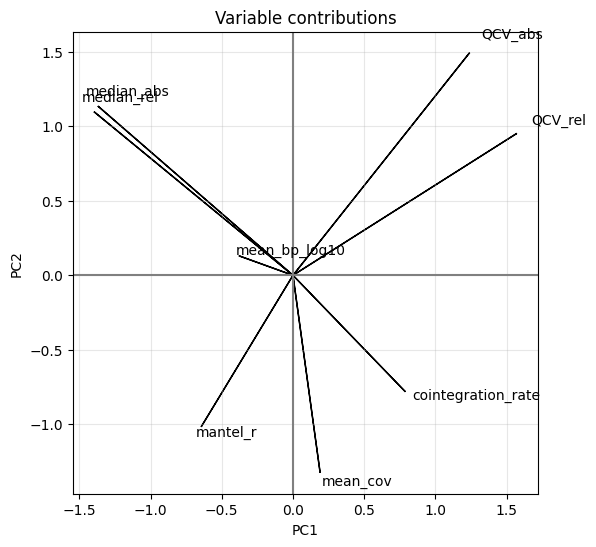

In [23]:
plt.figure(figsize=(6,6))
for i, var in enumerate(features):
    plt.arrow(0, 0,
              loadings.loc[var,"PC1"]*3,
              loadings.loc[var,"PC2"]*3)
    plt.text(loadings.loc[var,"PC1"]*3.2,
             loadings.loc[var,"PC2"]*3.2,
             var)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(0,color="grey")
plt.axvline(0,color="grey")
plt.title("Variable contributions")
plt.grid(alpha=0.3)
plt.show()

In [24]:
from sklearn.metrics import silhouette_score

for k in range(2,6):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={sil:.3f}")

k=2, silhouette=0.241
k=3, silhouette=0.250
k=4, silhouette=0.204
k=5, silhouette=0.201


In [25]:
eta2 = F_obs / (F_obs + (len(groups)-len(unique_groups)))
print("Approx eta2:", eta2)

Approx eta2: 0.0001393042242017419


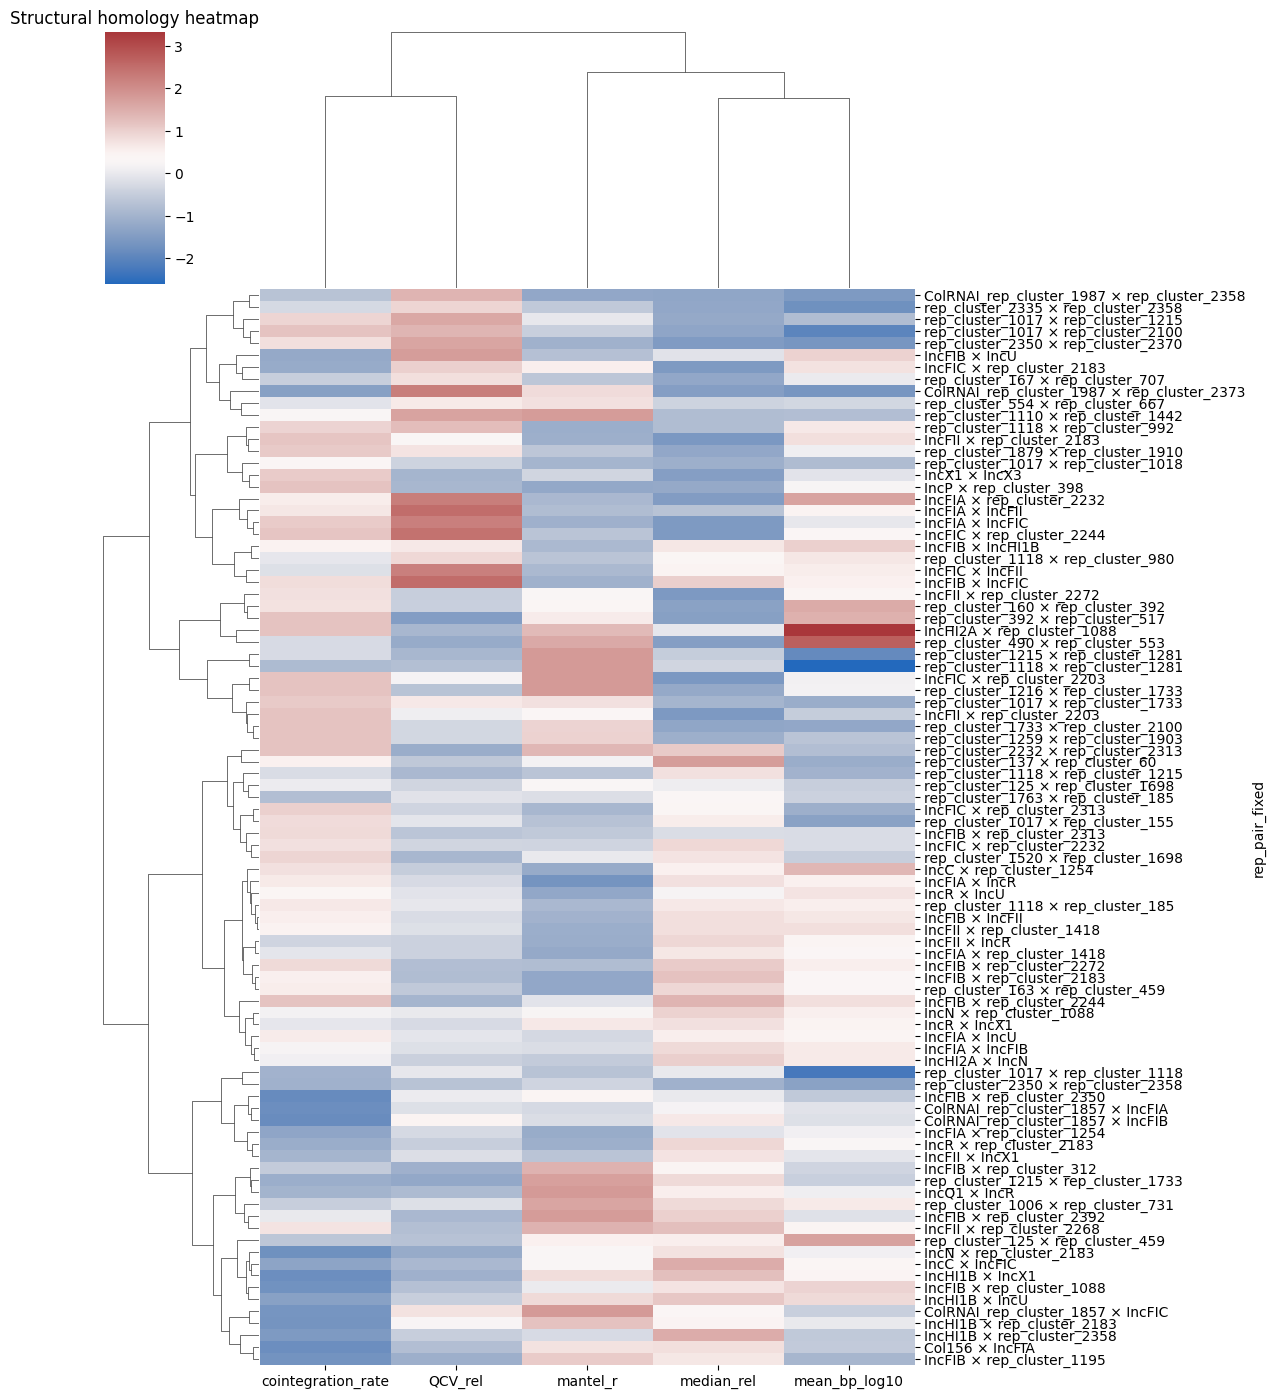

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# Selección de variables
# --------------------------------------------

features = [
    "cointegration_rate",
    "median_rel",
    "QCV_rel",
    "mantel_r",
    "mean_bp_log10",
]

data = full[features].dropna()
pair_ids = full.loc[data.index, "rep_pair_fixed"]

# --------------------------------------------
# Estandarización (CRÍTICO)
# --------------------------------------------

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(
    data_scaled,
    index=pair_ids,
    columns=features
)

# --------------------------------------------
# Clustermap
# --------------------------------------------

sns.clustermap(
    data_scaled,
    method="ward",
    metric="euclidean",
    cmap="vlag",
    figsize=(12,14),
    xticklabels=True,
    yticklabels=True
)

plt.title("Structural homology heatmap")
plt.show()

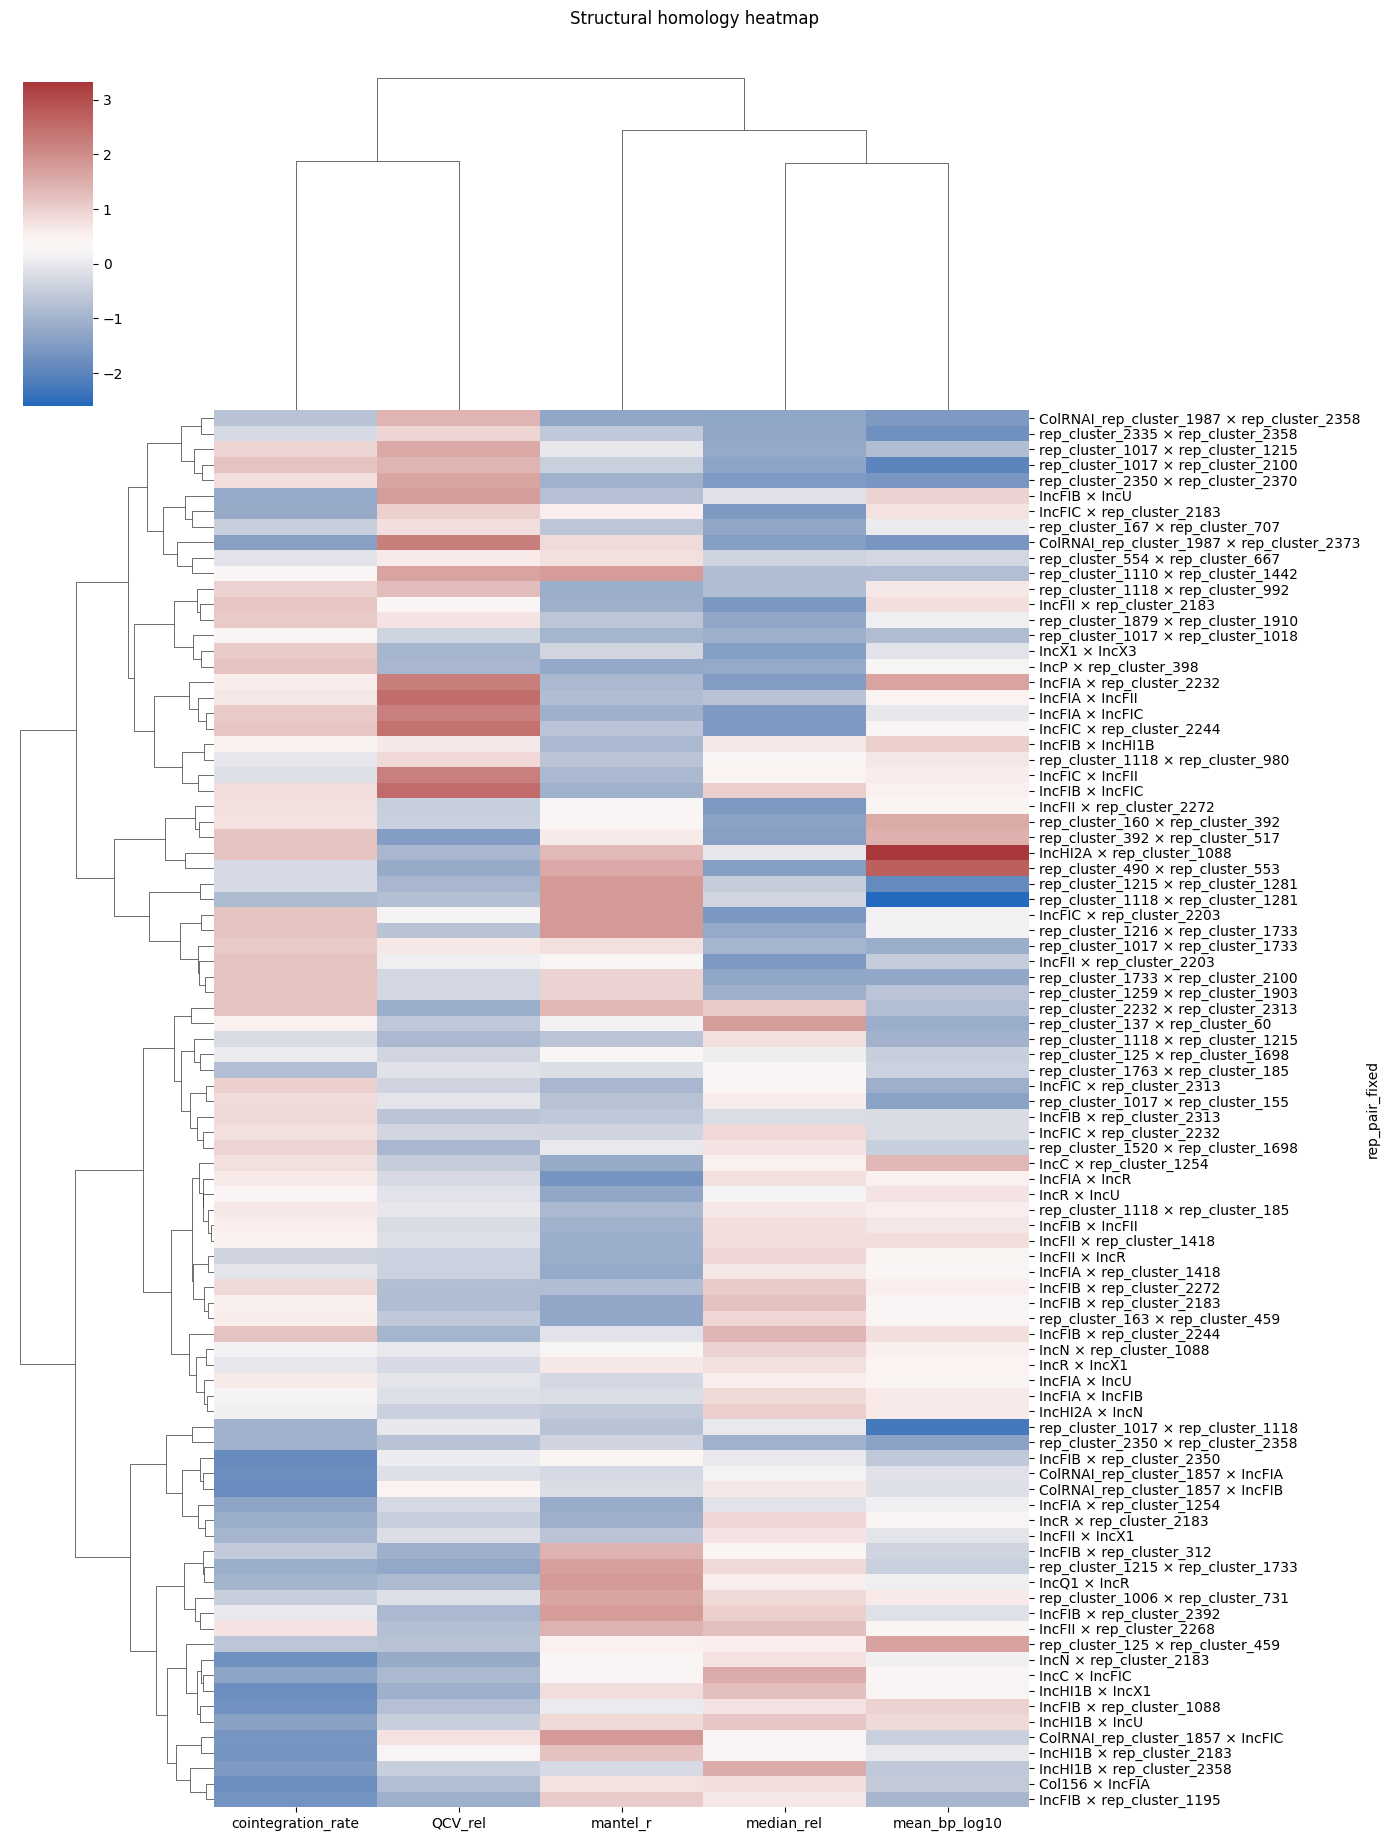

In [32]:
g = sns.clustermap(
    data_scaled,
    method="ward",
    metric="euclidean",
    cmap="vlag",
    figsize=(14,18),
    xticklabels=True,
    yticklabels=True
)

g.fig.suptitle("Structural homology heatmap", y=1.02)

# Guardar en alta resolución
g.fig.savefig(
    "structural_homology_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)